Population mean = 40.04 min, Population SD = 7.99 min

    n   Mean of sample means    SE = σ/√n   SD of sample means
   10                  40.03         2.53                 2.49
   30                  40.06         1.46                 1.52
  100                  40.01         0.80                 0.81


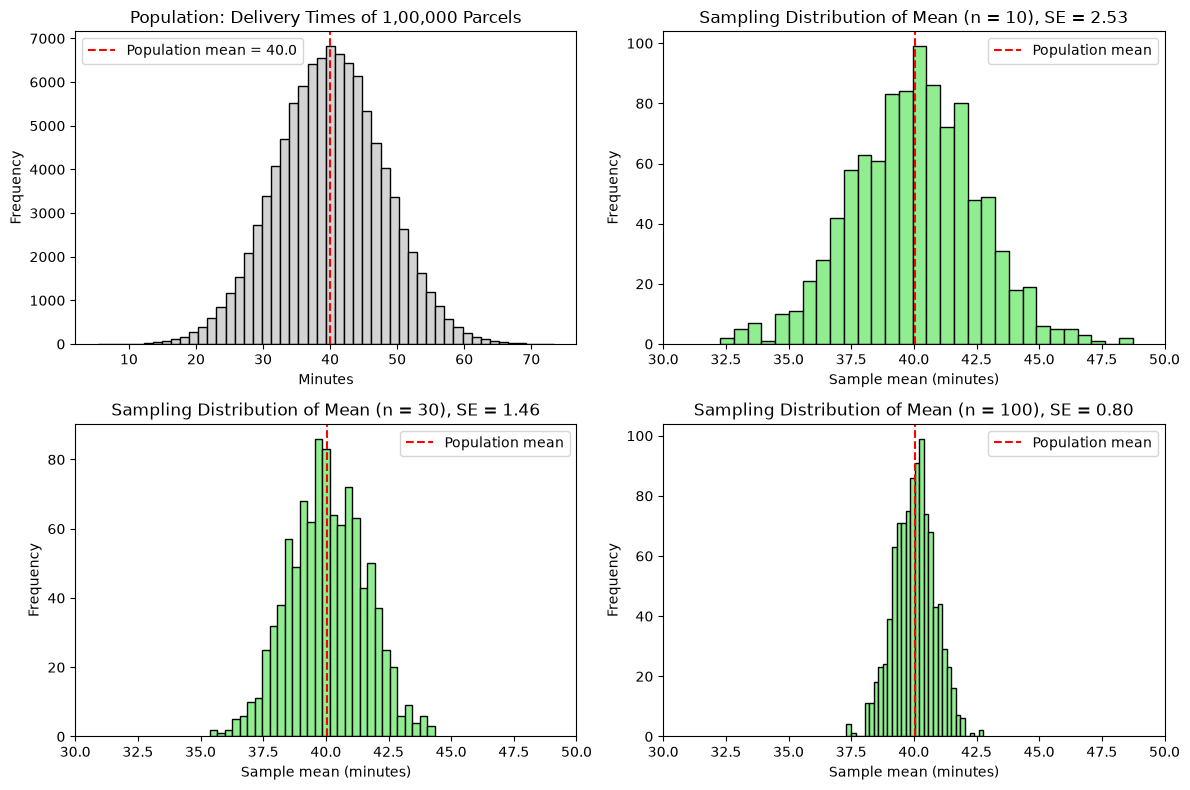


One sample of 30 parcels: mean = 39.50, estimated SE = s/√n = 1.28


In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# Step 1: Population of delivery times (minutes)
population = np.random.normal(loc=40, scale=8, size=100000)

mu, sigma = population.mean(), population.std()

print(f"Population mean = {mu:.2f} min, Population SD = {sigma:.2f} min\n")

# Step 2: Take 1000 samples for each sample size and store their means
sample_sizes = [10, 30, 100]
num_samples = 1000

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.ravel()

# Population histogram
ax[0].hist(population, bins=50, color='lightgray', edgecolor='black')

ax[0].axvline(
    mu,
    color='red',
    linestyle='--',
    label=f'Population mean = {mu:.1f}'
)

ax[0].set_title('Population: Delivery Times of 1,00,000 Parcels')
ax[0].set_xlabel('Minutes')
ax[0].set_ylabel('Frequency')
ax[0].legend()

# Header
print(
    f"{'n':>5} "
    f"{'Mean of sample means':>22} "
    f"{'SE = σ/√n':>12} "
    f"{'SD of sample means':>20}"
)

# Sampling distributions
for i, n in enumerate(sample_sizes):

    sample_means = [
        np.random.choice(population, size=n, replace=False).mean()
        for _ in range(num_samples)
    ]

    se_formula = sigma / np.sqrt(n)
    se_observed = np.std(sample_means)

    print(
        f"{n:>5} "
        f"{np.mean(sample_means):>22.2f} "
        f"{se_formula:>12.2f} "
        f"{se_observed:>20.2f}"
    )

    ax[i + 1].hist(
        sample_means,
        bins=30,
        color='lightgreen',
        edgecolor='black'
    )

    ax[i + 1].axvline(
        mu,
        color='red',
        linestyle='--',
        label='Population mean'
    )

    # Same scale so spread can be compared
    ax[i + 1].set_xlim(30, 50)

    ax[i + 1].set_title(
        f'Sampling Distribution of Mean (n = {n}), SE = {se_formula:.2f}'
    )

    ax[i + 1].set_xlabel('Sample mean (minutes)')
    ax[i + 1].set_ylabel('Frequency')
    ax[i + 1].legend()

plt.tight_layout()
plt.show()

# Step 3: SE estimated from ONE sample of 30 parcels
# sigma is assumed unknown, so use sample SD (s)
one_sample = np.random.choice(
    population,
    size=30,
    replace=False
)

se_est = one_sample.std(ddof=1) / np.sqrt(30)

print(
    f"\nOne sample of 30 parcels: "
    f"mean = {one_sample.mean():.2f}, "
    f"estimated SE = s/√n = {se_est:.2f}"
)